In [2]:
import pygame as pg
import numpy as np
import matplotlib.pyplot as plt

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
correction_coefficient = 0.5
gravity = 9.98 

In [13]:
class vertice:
    def __init__(self, pos, fixed):
        self.curr_pos = np.array(pos, dtype=float)
        self.last_pos = np.array(pos, dtype=float)
        self.fixed = fixed

class edge:
    def __init__(self, p1, p2, rigidness:float = 1):
        self.p1 = p1
        self.p2 = p2
        self.rigid = rigidness
        self.rest_length = np.linalg.norm(p1.curr_pos - p2.curr_pos)

def update_point(p, g:np.ndarray = np.array([0, 500]), dt = 1/60, damp = 0.99):
    if p.fixed:
        return False

    v = p.curr_pos - p.last_pos

    p.last_pos = p.curr_pos.copy()

    p.curr_pos += v * damp
    p.curr_pos += g * dt * dt

    return True

def solve_edge(edge, corr_coef:float = 0.5):
    p1 = edge.p1
    p2 = edge.p2

    delta = p2.curr_pos - p1.curr_pos

    distance = np.linalg.norm(delta)

    if distance==0:
        return False

    diff = distance - edge.rest_length

    direction = delta/distance

    push = direction * diff * corr_coef

    if not p1.fixed:
        p1.curr_pos += push

    if not p2.fixed:
        p2.curr_pos -= push

    return True

def build_mesh(n:int, m:int, spacing:int = 20, style:str = 'clothesline'):

    pos_matrix = []

    for i in range(n+1):
        
        curr_line = []
        
        for j in range(m+1):

           curr_line.append((i * spacing, j * spacing))

        pos_matrix.append(curr_line)


    for row_id, i in enumerate(pos_matrix):

        if style == 'flag':

            i[0] = vertice(i[0], fixed=True)

            for idx in range(1, len(i)):

                i[idx] = vertice(i[idx], fixed=False)

        elif style == 'sidehang':

            i[0] = vertice(i[0], fixed=True)
            i[m] = vertice(i[m], fixed=True)

            for idx in range(1, len(i)-1):

                i[idx] = vertice(i[idx], fixed=False)
        
        elif style == 'clothesline':

            if row_id == 0:

                for idx in range(len(i)):

                    i[idx] = vertice(i[idx], fixed=True)

                continue

            for idx in range(len(i)):

                i[idx] = vertice(i[idx], fixed=False)

        else:
            raise NotImplementedError('Não fiz essa opção ainda meu fi')

    return pos_matrix

edges = []
n, m = (10, 10)
vertices = build_mesh(n, m)

for i in range(n+1):
    for j in range(m+1):

        if i < n:
            edges.append(
                edge(vertices[i][j], vertices[i+1][j])
            )

        if j < m:
            edges.append(
                edge(vertices[i][j], vertices[i][j+1])
            )

pg.init()
running = True
screen = pg.display.set_mode((1280, 720))
clock = pg.time.Clock()
edge_iter = 10

while running:
    # poll for events
    # pg.QUIT event means the user clicked X to close your window
    for event in pg.event.get():
        if event.type == pg.QUIT:
            running = False

    screen.fill('black')

    for i in vertices:
        for k in i:
            update_point(k)

    for _ in range(edge_iter):

        for i in edges:
            solve_edge(i)

    for e in edges:

        pg.draw.line(
            screen,
            (255,255,255),
            e.p1.curr_pos,
            e.p2.curr_pos
        )

    pg.display.flip()
    clock.tick(60)



KeyboardInterrupt: 

In [ ]:
class vertex:
    def __init__(self, pos: tuple, fixed:bool = False):
        x, y = pos
        self.pos = np.array([x, y], dtype = float)
        self.old_pos = np.array([x, y], dtype = float)
        self.fixed = fixed

class Edge:
    def __init__(self, p1:vertex, p2:vertex):
        self.p1 = p1
        self.p2 = p2
        self.rest_length = np.linalg.norm(p2.pos - p1.pos)

def update_point(p, gravity, dt):

    if p.fixed:
        return

    velocity = p.pos - p.old_pos

    p.old_pos = p.pos.copy()

    damping = 0.99

    p.pos += velocity * damping
    p.pos += gravity * dt * dt

def solve_edge(edge):

    p1 = edge.p1
    p2 = edge.p2

    delta = p2.pos - p1.pos

    dist = np.linalg.norm(delta)

    if dist == 0:
        return

    diff = (dist - edge.rest_length) / dist

    correction = delta * 0.5 * diff

    if not p1.fixed:
        p1.pos += correction

    if not p2.fixed:
        p2.pos -= correction



edges = []
n, m = (10, 10)
vertices = build_mesh(n, m)

for i in range(n):
    for j in range(m):

        if i < n-1:
            edges.append(
                Edge(vertices[i][j], vertices[i+1][j])
            )

        if j < m-1:
            edges.append(
                Edge(vertices[i][j], vertices[i][j+1])
            )

pg.init()
screen = pg.display.set_mode((1280, 720))
clock = pg.time.Clock()
running = True
dt = 0

while running:

    # eventos
    for event in pg.event.get():

        if event.type == pg.QUIT:
            running = False

    # física
    for p in vertices:
        update_point(p, gravity, dt)

    for _ in range(10):

        for edge in edges:
            solve_edge(edge)

    for p in vertices:

        if p.pos[1] > HEIGHT:
            p.pos[1] = HEIGHT

        if p.pos[0] < 0:
            p.pos[0] = 0

        if p.pos[0] > WIDTH:
            p.pos[0] = WIDTH

        screen.fill((30,30,30))

        for edge in edges:

            pygame.draw.line(
                screen,
                (220,220,220),
                edge.p1.pos,
                edge.p2.pos,
                2
            )
        
        for p in vertices:

            color = (255,0,0) if p.fixed else (255,255,255)

            pygame.draw.circle(
                screen,
                color,
                p.pos.astype(int),
                3
            )


        pygame.display.flip()
        clock.tick(60)

SyntaxError: can't use starred expression here (560699628.py, line 105)

In [47]:
edges

In [33]:
teste = build_mesh(4, 5)

In [41]:
teste

array([[<__main__.vertex object at 0x7ade7524c440>,
        <__main__.vertex object at 0x7adb6cd48860>]], dtype=object)

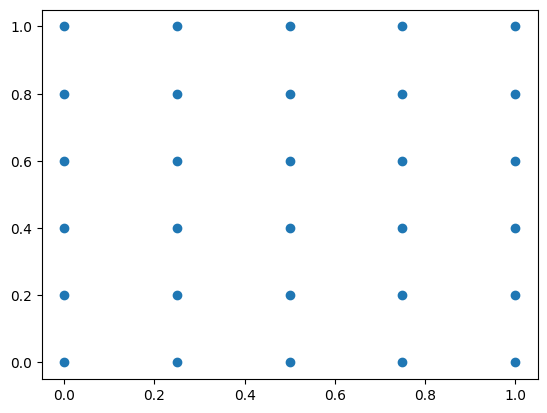

In [38]:
plt.scatter(x, y)